# Chai & Code: What a Year of Café Orders Can Teach a Beginner Data Analyst

**Author:** Manindra Shukla  
**Program:** Yuva Intern by Henry Harvin, Data Science Track (Project 2)  
**GitHub:** [github.com/Manindra07](https://github.com/Manindra07)  
**Email:** manindrashukla77@gmail.com

> *"Every dataset is a story someone forgot to tell properly. My job is to tidy it up until it talks."*

---

### Why this notebook looks a little different
Most beginner projects load the Titanic or Iris data, run `.describe()`, draw five charts and stop. I wanted to do something closer to what a real analyst faces on day one: **a messy dataset, a business question, and a boss who wants an answer.**

So I invented a café chain called **Chai & Code** (8 outlets, 5 cities, campus / mall / street formats) and generated a *deliberately dirty* year of order data (2025) for it. The dirt is realistic: inconsistent labels, mixed date formats, prices with a `₹` sign, duplicate rows, missing values and impossible delivery times.

>  **Honest disclosure:** the data is **synthetic**, generated in Section 2 with a fixed random seed, so the notebook is 100% reproducible. I planted a few real-world-style patterns (tea in winter, cold drinks in summer, slow delivery hurting ratings). The goal is to demonstrate the **workflow and thinking**, not to claim findings about a real business.

### The four questions I want to answer
1. **What sells, and when?** (seasonality and time-of-day patterns)
2. **Does delivery speed actually drive customer ratings?**
3. **Which outlet formats are healthiest?**
4. **Do discounts make people buy more, and is it worth it?**

### Roadmap
| # | Section | Objective covered |
|---|---------|------------------|
| 1 | Environment setup | Python, Jupyter, core libraries |
| 2 | Building the messy dataset | Loading data |
| 3 | First look at the raw data | Selection, filtering, sorting, quality audit |
| 4 | Cleaning | Missing values, duplicates, inconsistencies, dtypes |
| 5 | Pandas workout | Group-by, aggregation, merging, transformation |
| 6 | NumPy corner | Numerical operations |
| 7 | Visual storytelling | Matplotlib + Seaborn |
| 8 | Statistics | Descriptive stats, correlation, hypothesis testing |
| 9 | Bonus: a small ML model | Scikit-learn |
| 10 | Insights & recommendations | Conclusions, limitations |

## 1. Setting up the workspace

**How I set this up (on Windows/macOS/Linux):**
```bash
python -m venv venv
source venv/bin/activate          # Windows: venv\Scripts\activate
pip install -r requirements.txt
jupyter notebook
```
A virtual environment keeps this project's library versions from clashing with anything else on my machine, which is also what makes the notebook reproducible for anyone who clones it.

The cell below prints my versions, so anyone reading knows exactly what this ran on.

In [1]:
import sys, platform, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import stats
import sklearn

warnings.filterwarnings("ignore")

print(f"Python      : {sys.version.split()[0]} ({platform.system()})")
for lib in (np, pd, matplotlib, sns, scipy, sklearn):
    print(f"{lib.__name__:<11} : {lib.__version__}")

Python      : 3.12.3 (Linux)
numpy       : 2.4.4
pandas      : 3.0.2
matplotlib  : 3.10.8
seaborn     : 0.13.2
scipy       : 1.17.1
sklearn     : 1.8.0


In [2]:
# ---- Global settings: one place to change how the whole notebook behaves ----
SEED = 42                       # reproducibility: same seed -> same data -> same results
LATE_MINUTES = 30               # our delivery promise; anything above is "late"

for folder in ("data/raw", "data/clean", "images"):
    Path(folder).mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:,.2f}".format)

# A small "chai" palette so every chart feels like it belongs to the same story
CHAI = {"tea": "#B5651D", "milk": "#F2E3C6", "leaf": "#4F7942", "cup": "#3B2314", "spice": "#D9822B", "sky": "#5B8DB8"}
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 13,
                     "axes.spines.top": False, "axes.spines.right": False})

def save_fig(name):
    plt.tight_layout()
    plt.savefig(f"images/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

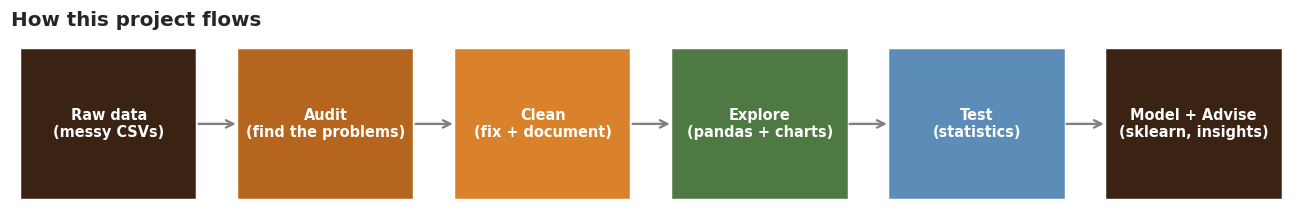

In [3]:
# A picture of the workflow, so the notebook reads like a story with a plan
steps = ["Raw data\n(messy CSVs)", "Audit\n(find the problems)", "Clean\n(fix + document)", "Explore\n(pandas + charts)", "Test\n(statistics)", "Model + Advise\n(sklearn, insights)"]
fig, ax = plt.subplots(figsize=(12, 2.2))
for i, t in enumerate(steps):
    ax.add_patch(plt.Rectangle((i * 2.0, 0), 1.6, 1, color=[CHAI["cup"], CHAI["tea"], CHAI["spice"], CHAI["leaf"], CHAI["sky"], CHAI["cup"]][i], zorder=2))
    ax.text(i * 2.0 + .8, .5, t, ha="center", va="center", color="white", fontsize=9.5, fontweight="bold", zorder=3)
    if i < len(steps) - 1:
        ax.annotate("", xy=(i * 2.0 + 2.0, .5), xytext=(i * 2.0 + 1.6, .5), arrowprops=dict(arrowstyle="->", color="grey", lw=1.5))
ax.set_xlim(-.1, len(steps) * 2.0 - .3); ax.set_ylim(-.1, 1.1); ax.axis("off")
ax.set_title("How this project flows", loc="left")
save_fig("00_workflow")

## 2. Building the messy dataset

Three tables, just like a real database:

* **`menu`**: 13 items with category and price
* **`stores`**: 8 outlets with city, format and opening year
* **`orders`**: ~3,000 transactions (the big, messy one)

I generate the clean version first, then **inject realistic mess on purpose**, so I know exactly what to look for during cleaning. The raw files are saved to `data/raw/` and I then *reload them from disk*, which is what a real workflow looks like.

In [4]:
rng = np.random.default_rng(SEED)
N = 3000

# ---------- Reference tables ----------
menu = pd.DataFrame({
    "item":       ["Masala Chai","Cutting Chai","Ginger Tea","Filter Coffee","Espresso","Cold Coffee","Mango Shake",
                   "Samosa","Bun Maska","Veg Sandwich","Maggi","Brownie","Cheesecake"],
    "category":   ["Tea","Tea","Tea","Coffee","Coffee","Cold Drinks","Cold Drinks",
                   "Snacks","Snacks","Snacks","Snacks","Dessert","Dessert"],
    "unit_price": [30,20,35,60,80,120,100,25,40,90,70,110,150],
})
stores = pd.DataFrame({
    "store_id":    [f"S{i:02d}" for i in range(1, 9)],
    "city":        ["Lucknow","Lucknow","Delhi","Delhi","Pune","Pune","Jaipur","Indore"],
    "store_type":  ["Campus","Mall","Campus","Street","Mall","Campus","Street","Street"],
    "opened_year": [2019,2021,2018,2020,2022,2021,2023,2022],
})

# ---------- Order dates: weekends are busier ----------
all_days = pd.date_range("2025-01-01", "2025-12-31")
day_w = np.where(all_days.dayofweek >= 5, 1.5, 1.0)
dates = pd.DatetimeIndex(rng.choice(all_days, N, p=day_w / day_w.sum()))
month = dates.month.values

# ---------- What people order depends on the season ----------
cat = menu["category"].values
base_w = np.array([14,12,8,7,5,6,4,10,8,6,7,4,2], dtype=float)
chosen = []
for m in month:
    w = base_w.copy()
    if m in (4, 5, 6):            # peak summer
        w *= np.where(cat == "Cold Drinks", 3.0, 1.0) * np.where(cat == "Tea", 0.6, 1.0)
    if m in (11, 12, 1, 2):       # winter
        w *= np.where(cat == "Tea", 1.8, 1.0) * np.where(cat == "Coffee", 1.3, 1.0)
    chosen.append(rng.choice(menu["item"].values, p=w / w.sum()))
chosen = np.array(chosen)

# ---------- Store, hour, discount, quantity, payment ----------
store_ids = rng.choice(stores["store_id"], N, p=[.16,.10,.15,.14,.10,.13,.10,.12])
type_of = stores.set_index("store_id")["store_type"]
hour_w = np.array([3,5,4,3,7,9,5,3,4,7,9,8,6,4,2], dtype=float)
hours = rng.choice(np.arange(8, 23), N, p=hour_w / hour_w.sum())
disc = rng.choice([0,5,10,15,20], N, p=[.40,.20,.20,.12,.08])
qty_normal = rng.choice([1,2,3,4], N, p=[.50,.30,.14,.06])
qty_promo  = rng.choice([1,2,3,4], N, p=[.32,.36,.22,.10])
qty = np.where(disc >= 15, qty_promo, qty_normal)          # bigger discount -> slightly bigger baskets
pay = rng.choice(["UPI","Card","Cash","Wallet"], N, p=[.55,.20,.18,.07])

# ---------- Delivery time and rating ----------
type_effect = pd.Series(store_ids).map(type_of).map({"Campus": 0, "Mall": 6, "Street": 3}).values
is_peak = np.isin(hours, [12, 13, 19, 20])
is_rainy = np.isin(month, [7, 8, 9])
delivery = np.clip(18 + type_effect + 7*is_peak + 5*is_rainy + rng.normal(0, 4, N), 8, None).round(1)
rating = np.clip(np.round(5.2 - 0.07*(delivery - 20) + rng.normal(0, 0.6, N)), 1, 5)

orders = pd.DataFrame({
    "order_id": [f"ORD-{i:05d}" for i in range(1, N + 1)],
    "order_date": dates,
    "order_hour": hours,
    "store_id": store_ids,
    "customer_id": [f"C{c:04d}" for c in rng.integers(1, 901, N)],
    "item": chosen,
    "quantity": qty,
    "unit_price": menu.set_index("item").loc[chosen, "unit_price"].values,
    "discount_pct": disc,
    "payment_mode": pay,
    "delivery_minutes": delivery,
    "rating": rating,
}).sort_values("order_date").reset_index(drop=True)
print("Clean 'ground truth' built:", orders.shape)

Clean 'ground truth' built: (3000, 12)


### Now let's make it dirty
Here's my "crime list". I'll try to find every item on it during cleaning:

| Problem | How I broke it |
|---|---|
| Mixed date formats | ~10% of dates written as `DD/MM/YYYY` |
| Inconsistent IDs | lowercase and whitespace in `store_id` |
| Payment label chaos | `upi`, `Upi `, `GPay`, `PhonePe`, `CARD`, `cash ` ... |
| Wrong data type | ~10% of prices stored as text like `₹120` |
| Item name typos | lowercase + trailing spaces |
| Missing values | rating (~12%), delivery time (~5%), payment (~2%), customer (~1%) |
| Impossible values | delivery of 300-999 minutes, and negative minutes |
| Duplicate records | 60 rows copied exactly |

In [5]:
messy = orders.copy()
n = len(messy)

# 1) mixed date formats (stored as text)
messy["order_date"] = messy["order_date"].dt.strftime("%Y-%m-%d")
alt = rng.random(n) < 0.10
messy.loc[alt, "order_date"] = pd.to_datetime(messy.loc[alt, "order_date"]).dt.strftime("%d/%m/%Y")

# 2) store id formatting
low = rng.random(n) < 0.08;  messy.loc[low, "store_id"] = messy.loc[low, "store_id"].str.lower()
pad = rng.random(n) < 0.05;  messy.loc[pad, "store_id"] = " " + messy.loc[pad, "store_id"] + " "

# 3) payment label chaos
variants = {"UPI": ["upi","Upi ","GPay","PhonePe"], "Card": ["card","CARD"], "Cash": ["cash","CASH "], "Wallet": ["wallet"]}
m = rng.random(n) < 0.22
messy.loc[m, "payment_mode"] = [rng.choice(variants[p]) for p in messy.loc[m, "payment_mode"]]

# 4) price stored as text with a rupee sign
messy["unit_price"] = messy["unit_price"].astype(object)
m = rng.random(n) < 0.10
messy.loc[m, "unit_price"] = messy.loc[m, "unit_price"].map(lambda x: f"₹{x}")

# 5) item name typos
m = rng.random(n) < 0.04
messy.loc[m, "item"] = messy.loc[m, "item"].str.lower() + " "

# 6) impossible delivery values
idx = rng.choice(n, 20, replace=False)
messy.loc[idx[:12], "delivery_minutes"] = rng.integers(300, 999, 12)
messy.loc[idx[12:], "delivery_minutes"] = -rng.integers(1, 20, 8)

# 7) missing values
for col, frac in {"rating": .12, "delivery_minutes": .05, "payment_mode": .02, "customer_id": .01}.items():
    messy.loc[rng.random(n) < frac, col] = np.nan

# 8) exact duplicate rows, then shuffle so they are hidden in the crowd
messy = pd.concat([messy, messy.sample(60, random_state=SEED)]).sample(frac=1, random_state=SEED).reset_index(drop=True)

# save like a real project: raw files on disk, never edited by hand
messy.to_csv("data/raw/orders_raw.csv", index=False, encoding="utf-8")
menu.to_csv("data/raw/menu.csv", index=False)
stores.to_csv("data/raw/stores.csv", index=False)
print("Saved raw files:", [p.name for p in Path("data/raw").glob("*.csv")])

Saved raw files: ['menu.csv', 'orders_raw.csv', 'stores.csv']


In [6]:
# Reload from disk, exactly like a fresh analyst would
orders_raw = pd.read_csv("data/raw/orders_raw.csv")
menu       = pd.read_csv("data/raw/menu.csv")
stores     = pd.read_csv("data/raw/stores.csv")
orders_raw.head(8)

,order_id,order_date,order_hour,store_id,customer_id,item,quantity,unit_price,discount_pct,payment_mode,delivery_minutes,rating
0,ORD-01095,2025-08-02,20,S06,C0845,Cutting Chai,4,20,0,Cash,22.80,4.00
1,ORD-02340,2025-01-26,12,S06,C0292,Cutting Chai,1,20,5,Cash,28.20,5.00
2,ORD-02832,2025-06-14,12,s05,C0534,Espresso,1,80,5,UPI,30.70,4.00
3,ORD-00384,2025-06-24,21,S06,C0180,Mango Shake,3,100,0,UPI,18.70,5.00
4,ORD-00356,2025-07-10,13,S04,C0490,Ginger Tea,1,35,5,upi,34.00,5.00
5,ORD-00422,2025-01-14,8,s04,C0006,Cutting Chai,1,20,0,CARD,20.20,5.00
6,ORD-01372,2025-12-13,8,S07,C0565,Masala Chai,2,30,5,Upi,18.50,4.00
7,ORD-00524,2025-08-08,16,S02,C0373,Filter Coffee,1,60,0,Wallet,29.80,5.00


## 3. First look at the raw data

Rule I'm following: **never trust a dataset until you've interrogated it.** I start with shape, types, missing values and duplicates, plus a quick tour of selection, filtering and sorting.

In [7]:
print("Shape:", orders_raw.shape)
print()
orders_raw.info()

Shape: (3060, 12)

<class 'pandas.DataFrame'>
RangeIndex: 3060 entries, 0 to 3059
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          3060 non-null   str    
 1   order_date        3060 non-null   str    
 2   order_hour        3060 non-null   int64  
 3   store_id          3060 non-null   str    
 4   customer_id       3029 non-null   str    
 5   item              3060 non-null   str    
 6   quantity          3060 non-null   int64  
 7   unit_price        3060 non-null   str    
 8   discount_pct      3060 non-null   int64  
 9   payment_mode      3008 non-null   str    
 10  delivery_minutes  2879 non-null   float64
 11  rating            2715 non-null   float64
dtypes: float64(2), int64(3), str(7)
memory usage: 287.0 KB


In [8]:
audit = pd.DataFrame({
    "dtype": orders_raw.dtypes.astype(str),
    "missing": orders_raw.isna().sum(),
    "missing_%": (orders_raw.isna().mean() * 100).round(1),
    "unique_values": orders_raw.nunique(),
})
print("Exact duplicate rows:", orders_raw.duplicated().sum())
audit

Exact duplicate rows: 60


,dtype,missing,missing_%,unique_values
order_id,str,0,0.00,3000
order_date,str,0,0.00,575
order_hour,int64,0,0.00,15
store_id,str,0,0.00,30
customer_id,str,31,1.00,863
item,str,0,0.00,26
quantity,int64,0,0.00,4
unit_price,str,0,0.00,26
discount_pct,int64,0,0.00,5
payment_mode,str,52,1.70,13


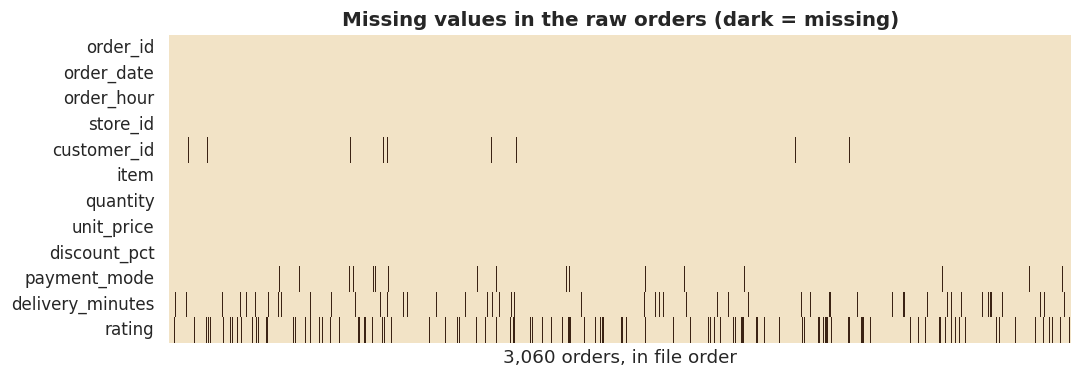

In [9]:
# Where exactly are the holes? Each column is one order; dark marks = missing value.
fig, ax = plt.subplots(figsize=(10, 3.6))
sns.heatmap(orders_raw.isna().T, cbar=False, cmap=["#F2E3C6", "#3B2314"], yticklabels=True, xticklabels=False, ax=ax)
ax.set(title="Missing values in the raw orders (dark = missing)", xlabel="3,060 orders, in file order")
save_fig("01a_missing_values_raw")

**What jumps out already:**
* `unit_price` is `object` (text), not numeric, so the `₹` symbols are the culprit.
* `order_date` is also text, so no date maths is possible yet.
* `payment_mode` has far more unique values than the 4 real payment methods.
* `store_id` has more than 8 unique values for 8 stores, which means formatting problems.
* `rating` has the most missing values.

In [10]:
# Selection, filtering and sorting on the raw data (warm-up)

# 1) Column selection
print(orders_raw[["order_id", "item", "quantity"]].head(3), "\n")

# 2) Label-based (.loc) and position-based (.iloc) selection
print(orders_raw.loc[0:2, ["order_id", "rating"]], "\n")
print(orders_raw.iloc[0:3, 0:4], "\n")

# 3) Boolean filtering: big baskets with a high discount
big = orders_raw[(orders_raw["quantity"] >= 3) & (orders_raw["discount_pct"] >= 15)]
print(f"Big-basket promo orders: {len(big)}\n")

# 4) .query() reads like English
print(orders_raw.query("delivery_minutes > 200").sort_values("delivery_minutes", ascending=False)[["order_id","delivery_minutes"]].head(5))

    order_id          item  quantity
0  ORD-01095  Cutting Chai         4
1  ORD-02340  Cutting Chai         1
2  ORD-02832      Espresso         1 

    order_id  rating
0  ORD-01095    4.00
1  ORD-02340    5.00
2  ORD-02832    4.00 

    order_id  order_date  order_hour store_id
0  ORD-01095  2025-08-02          20      S06
1  ORD-02340  2025-01-26          12     S06 
2  ORD-02832  2025-06-14          12      s05 

Big-basket promo orders: 204

       order_id  delivery_minutes
1558  ORD-00769            969.00
1105  ORD-02090            944.00
99    ORD-00716            911.00
876   ORD-00855            720.00
2671  ORD-01824            594.00


In [11]:
# The messy labels, made visible
print("payment_mode labels:\n", orders_raw["payment_mode"].value_counts(dropna=False).to_string(), "\n")
print("store_id labels:", sorted(orders_raw["store_id"].dropna().unique()))

payment_mode labels:
 payment_mode
UPI        1301
Cash        452
Card        439
Wallet      152
Upi         115
PhonePe      95
GPay         85
upi          84
CASH         68
CARD         62
cash         61
card         57
NaN          52
wallet       37 

store_id labels: [' S01 ', ' S02 ', ' S03 ', ' S04 ', ' S05 ', ' S06 ', ' S07 ', ' S08 ', ' s01 ', ' s03 ', ' s04 ', ' s05 ', ' s06 ', ' s08 ', 'S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 's01', 's02', 's03', 's04', 's05', 's06', 's07', 's08']


In [12]:
def scorecard(d):
    return pd.Series({
        "rows": len(d),
        "exact duplicate rows": int(d.duplicated().sum()),
        "missing cells": int(d.isna().sum().sum()),
        "distinct payment labels": d["payment_mode"].nunique(dropna=True),
        "distinct store_id labels": d["store_id"].nunique(dropna=True),
        "delivery values outside 5-120 min": int((~pd.to_numeric(d["delivery_minutes"]).between(5, 120) & d["delivery_minutes"].notna()).sum()),
    })

before = scorecard(orders_raw)
before.to_frame("BEFORE cleaning")

,BEFORE cleaning
rows,3060
exact duplicate rows,60
missing cells,609
distinct payment labels,13
distinct store_id labels,30
delivery values outside 5-120 min,19


## 4. Cleaning, step by step

My approach: **one issue, one fix, one check**, and I log every change so the cleaning is auditable. I work on a *copy* so the raw data is never touched.

**Decisions I'm making and why:**
| Problem | Decision | Reasoning |
|---|---|---|
| Duplicates | Drop | An order can't exist twice |
| Label inconsistencies | Standardise with a mapping | Same thing, different spelling |
| Missing payment mode | Fill with `"Unknown"` | Dropping loses valid revenue rows |
| Missing customer ID | Fill with `"GUEST"` | Walk-in customers are normal |
| Impossible delivery times | Convert to missing, then impute by store-type median | A 999-minute delivery is an entry error; the median is robust |
| Missing ratings | **Leave missing** | Ratings are optional. Inventing them would bias every rating analysis |

In [13]:
df = orders_raw.copy()
log = {}

# --- 1. Duplicates ---
n0 = len(df)
df = df.drop_duplicates().reset_index(drop=True)
log["Exact duplicate rows removed"] = n0 - len(df)
assert df["order_id"].is_unique, "order_id should be unique after de-duplication"

# --- 2. Text standardisation ---
df["store_id"] = df["store_id"].str.strip().str.upper()
df["item"] = df["item"].str.strip().str.title()

PAY_MAP = {"upi": "UPI", "gpay": "UPI", "phonepe": "UPI", "card": "Card", "cash": "Cash", "wallet": "Wallet"}
df["payment_mode"] = df["payment_mode"].str.strip().str.lower().map(PAY_MAP)
log["Missing payment_mode set to 'Unknown'"] = int(df["payment_mode"].isna().sum())
df["payment_mode"] = df["payment_mode"].fillna("Unknown")

log["Missing customer_id set to 'GUEST'"] = int(df["customer_id"].isna().sum())
df["customer_id"] = df["customer_id"].fillna("GUEST")

# --- 3. Fix data types: price text -> float ---
log["Prices that carried a ₹ sign"] = int(df["unit_price"].astype(str).str.contains("₹").sum())
df["unit_price"] = df["unit_price"].astype(str).str.replace("₹", "", regex=False).str.strip().astype(float)

# --- 4. Dates: try ISO first, then fall back to DD/MM/YYYY ---
iso = pd.to_datetime(df["order_date"], format="%Y-%m-%d", errors="coerce")
dmy = pd.to_datetime(df["order_date"], format="%d/%m/%Y", errors="coerce")
log["Dates rescued from DD/MM/YYYY"] = int(iso.isna().sum())
df["order_date"] = iso.fillna(dmy)
assert df["order_date"].notna().all(), "some dates could not be parsed"

pd.Series(log).to_frame("count")

,count
Exact duplicate rows removed,60
Missing payment_mode set to 'Unknown',52
Missing customer_id set to 'GUEST',31
Prices that carried a ₹ sign,279
Dates rescued from DD/MM/YYYY,315


In [14]:
# --- 5. Integrity checks via merging with the reference tables ---
df = df.merge(menu.rename(columns={"unit_price": "menu_price"}), on="item", how="left", validate="m:1")
df = df.merge(stores, on="store_id", how="left", validate="m:1")

print("Items not found in menu   :", df["menu_price"].isna().sum())
print("Stores not found in table :", df["city"].isna().sum())
print("Price mismatches vs menu  :", (df["unit_price"] != df["menu_price"]).sum())
df = df.drop(columns="menu_price")     # validated, no longer needed

Items not found in menu   : 0
Stores not found in table : 0
Price mismatches vs menu  : 0


Zero unmatched items, zero unmatched stores and zero price mismatches: **the text cleanup worked and the price fix didn't corrupt anything.** I'm using the merge as a validation tool here, not just a way to attach columns.

Now the numeric problems: impossible delivery times and missing values.

In [15]:
# --- 6. Delivery time: impossible values -> NaN -> imputed by store-type median ---
impossible = ~df["delivery_minutes"].between(5, 120) & df["delivery_minutes"].notna()
log["Delivery values impossible (<5 or >120 min)"] = int(impossible.sum())
df.loc[impossible, "delivery_minutes"] = np.nan

df["delivery_imputed"] = df["delivery_minutes"].isna()          # keep a flag: transparency
log["Delivery values imputed (missing + impossible)"] = int(df["delivery_imputed"].sum())
df["delivery_minutes"] = df["delivery_minutes"].fillna(df.groupby("store_type")["delivery_minutes"].transform("median"))

# --- 7. Ratings: deliberately left missing ---
df["has_rating"] = df["rating"].notna()
log["Ratings left missing on purpose"] = int((~df["has_rating"]).sum())

# --- 8. Memory-friendly dtypes ---
for c in ["store_id", "item", "category", "city", "store_type", "payment_mode"]:
    df[c] = df[c].astype("category")
df["quantity"] = df["quantity"].astype(int)

pd.Series(log).to_frame("count")

,count
Exact duplicate rows removed,60
Missing payment_mode set to 'Unknown',52
Missing customer_id set to 'GUEST',31
Prices that carried a ₹ sign,279
Dates rescued from DD/MM/YYYY,315
Delivery values impossible (<5 or >120 min),19
Delivery values imputed (missing + impossible),193
Ratings left missing on purpose,339


### Feature engineering
Cleaning fixes what's broken. Feature engineering creates what's *useful*: revenue, calendar features, day-part and a "late" flag that maps to our 30-minute promise.

In [16]:
df["revenue"]    = df["quantity"] * df["unit_price"] * (1 - df["discount_pct"] / 100)
df["month"]      = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.strftime("%b")
df["weekday"]    = pd.Categorical(df["order_date"].dt.day_name(),
                                  categories=["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"], ordered=True)
df["is_weekend"] = df["order_date"].dt.dayofweek >= 5
df["daypart"]    = pd.cut(df["order_hour"], bins=[7, 11, 15, 19, 23], labels=["Morning", "Lunch", "Evening", "Night"])
df["is_late"]    = df["delivery_minutes"] > LATE_MINUTES

df.to_csv("data/clean/orders_clean.csv", index=False)
after = scorecard(df.assign(payment_mode=df["payment_mode"].astype(str), store_id=df["store_id"].astype(str)))
pd.concat([before.rename("BEFORE"), after.rename("AFTER")], axis=1)

,BEFORE,AFTER
rows,3060,3000
exact duplicate rows,60,0
missing cells,609,339
distinct payment labels,13,5
distinct store_id labels,30,8
delivery values outside 5-120 min,19,0


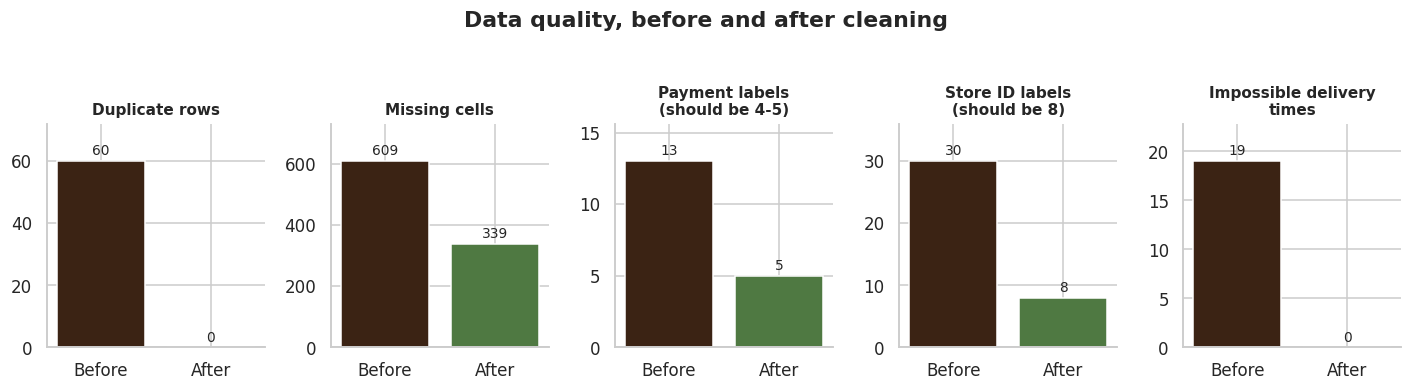

In [17]:
# Before vs after: five checks, side by side
checks = ["exact duplicate rows", "missing cells", "distinct payment labels", "distinct store_id labels", "delivery values outside 5-120 min"]
nice   = ["Duplicate rows", "Missing cells", "Payment labels\n(should be 4-5)", "Store ID labels\n(should be 8)", "Impossible delivery\ntimes"]
fig, axes = plt.subplots(1, 5, figsize=(13, 3.4))
for ax, c, n in zip(axes, checks, nice):
    bars = ax.bar(["Before", "After"], [before[c], after[c]], color=[CHAI["cup"], CHAI["leaf"]])
    ax.bar_label(bars, padding=2, fontsize=9)
    ax.set_title(n, fontsize=10); ax.set_ylim(0, max(before[c], after[c]) * 1.2)
fig.suptitle("Data quality, before and after cleaning", fontweight="bold", y=1.04)
save_fig("02a_cleaning_before_after")

In [18]:
print("Final shape:", df.shape)
df.dtypes.to_frame("dtype").T

Final shape: (3000, 25)


,order_id,order_date,order_hour,store_id,customer_id,item,quantity,unit_price,discount_pct,payment_mode,delivery_minutes,rating,category,city,store_type,opened_year,delivery_imputed,has_rating,revenue,month,month_name,weekday,is_weekend,daypart,is_late
dtype,str,datetime64[us],int64,category,str,category,int64,float64,int64,category,float64,float64,category,category,category,int64,bool,bool,float64,int32,str,category,bool,category,bool


**Cleaning verdict:** duplicates gone, labels consistent (4 payment modes plus `Unknown`, 8 stores), dates and prices are proper types, impossible delivery times handled and flagged. The only missing cells left are ratings, which is intentional.

## 5. Pandas workout: grouping, aggregation, merging, transformation

Now the clean data can start answering questions.

In [19]:
# Q1 (a): Category performance, using named aggregation
cat_perf = (df.groupby("category", observed=True)
              .agg(orders=("order_id", "count"),
                   revenue=("revenue", "sum"),
                   avg_order_value=("revenue", "mean"),
                   avg_qty=("quantity", "mean"),
                   avg_rating=("rating", "mean"))
              .sort_values("revenue", ascending=False))
cat_perf["revenue_share_%"] = cat_perf["revenue"] / cat_perf["revenue"].sum() * 100
cat_perf

,orders,revenue,avg_order_value,avg_qty,avg_rating,revenue_share_%
category,,,,,,
Cold Drinks,448,"89,761.00",200.36,1.92,4.67,30.17
Snacks,887,"77,871.25",87.79,1.85,4.66,26.17
Tea,1155,"54,381.50",47.08,1.86,4.70,18.28
Coffee,360,"40,321.00",112.00,1.77,4.64,13.55
Dessert,150,"35,210.50",234.74,2.02,4.62,11.83


In [20]:
# Q3: Outlet health, grouped by TWO keys and merged with the stores table
store_kpi = (df.groupby("store_id", observed=True)
               .agg(orders=("order_id", "count"), revenue=("revenue", "sum"),
                    avg_delivery=("delivery_minutes", "mean"), late_rate=("is_late", "mean"),
                    avg_rating=("rating", "mean"))
               .reset_index()
               .merge(stores, on="store_id"))
store_kpi["late_rate"] = store_kpi["late_rate"] * 100
store_kpi["revenue_per_year_open"] = store_kpi["revenue"] / (2025 - store_kpi["opened_year"] + 1)
store_kpi.sort_values("avg_rating", ascending=False)[["store_id","city","store_type","orders","revenue","avg_delivery","late_rate","avg_rating"]]

,store_id,city,store_type,orders,revenue,avg_delivery,late_rate,avg_rating
2,S03,Delhi,Campus,460,"44,926.75",21.58,8.48,4.79
0,S01,Lucknow,Campus,469,"48,700.50",22.22,8.74,4.77
5,S06,Pune,Campus,399,"38,184.75",21.85,8.27,4.72
3,S04,Delhi,Street,408,"42,056.00",25.23,17.65,4.66
6,S07,Jaipur,Street,284,"27,529.00",24.67,15.85,4.64
7,S08,Indore,Street,369,"36,883.25",25.20,20.33,4.61
4,S05,Pune,Mall,312,"29,859.00",27.52,29.81,4.54
1,S02,Lucknow,Mall,299,"29,406.00",28.52,36.12,4.52


In [21]:
# Q1 (b): Pivot table: which categories dominate which months?
season = df.pivot_table(index="month", columns="category", values="revenue", aggfunc="sum", observed=True)
season.round(0)

category,Coffee,Cold Drinks,Dessert,Snacks,Tea
month,,,,,
1,"2,762.00","4,252.00","2,406.00","4,989.00","5,254.00"
2,"3,823.00","3,668.00","1,566.00","4,443.00","6,946.00"
3,"3,869.00","6,480.00","3,090.00","7,094.00","4,986.00"
4,"3,153.00","15,157.00","2,953.00","4,314.00","2,621.00"
5,"2,955.00","14,897.00","3,143.00","7,621.00","2,057.00"
6,"3,720.00","17,857.00","3,528.00","6,620.00","2,441.00"
7,"4,602.00","5,314.00","3,873.00","6,786.00","4,225.00"
8,"1,674.00","7,592.00","2,340.00","9,615.00","4,560.00"
9,"3,162.00","2,414.00","4,479.00","6,747.00","3,933.00"


In [22]:
# Transformation with groupby().transform(): each order's share of its own city's revenue
df["pct_of_city_revenue"] = df["revenue"] / df.groupby("city", observed=True)["revenue"].transform("sum") * 100
# rank inside each store
df["rank_in_store"] = df.groupby("store_id", observed=True)["revenue"].rank(ascending=False, method="first")

print("Biggest single order in each store:")
df[df["rank_in_store"] == 1][["store_id", "city", "item", "quantity", "revenue"]].sort_values("store_id")

Biggest single order in each store:


,store_id,city,item,quantity,revenue
1063,S01,Lucknow,Cheesecake,4,510.00
1142,S02,Lucknow,Cheesecake,4,600.00
1870,S03,Delhi,Cheesecake,4,540.00
411,S04,Delhi,Cheesecake,4,600.00
1025,S05,Pune,Cold Coffee,4,480.00
341,S06,Pune,Cold Coffee,4,480.00
1370,S07,Jaipur,Cheesecake,4,600.00
2446,S08,Indore,Cheesecake,3,450.00


In [23]:
# A second merge: build a customer table (aggregation), then merge it back on customer_id
known = df[df["customer_id"] != "GUEST"]
customers = (known.groupby("customer_id")
                  .agg(visits=("order_id", "count"), lifetime_spend=("revenue", "sum"), last_visit=("order_date", "max"))
                  .reset_index())
customers["segment"] = pd.cut(customers["visits"], bins=[0, 2, 4, 100], labels=["Occasional", "Regular", "Loyal"])

df = df.merge(customers[["customer_id", "segment"]], on="customer_id", how="left")

print(customers["segment"].value_counts().to_string(), "\n")
print(f"Loyal customers = {(customers.segment=='Loyal').mean():.1%} of customers, "
      f"but {customers.loc[customers.segment=='Loyal','lifetime_spend'].sum() / customers['lifetime_spend'].sum():.1%} of spend")

segment
Regular       382
Occasional    280
Loyal         201 

Loyal customers = 23.3% of customers, but 39.9% of spend


In [24]:
# map / apply: a simple price tier
df["price_tier"] = pd.cut(df["unit_price"], bins=[0, 50, 100, 200], labels=["Budget", "Mid", "Premium"])
df.groupby("price_tier", observed=True)["revenue"].agg(["count", "sum"]).rename(columns={"count": "orders", "sum": "revenue"})

,orders,revenue
price_tier,,
Budget,1672,"82,844.25"
Mid,923,"124,494.50"
Premium,405,"90,206.50"


## 6. NumPy corner

Pandas is built on NumPy, so it's worth knowing what's underneath: vectorised maths, broadcasting, boolean masks and random sampling.

In [25]:
rev = df["revenue"].to_numpy()

print(f"mean {rev.mean():.1f} | median {np.median(rev):.1f} | std {rev.std():.1f}")
print("percentiles (25/50/75/95):", np.percentile(rev, [25, 50, 75, 95]).round(1))

# z-scores to spot unusually large orders
z = (rev - rev.mean()) / rev.std()
print(f"Orders with |z| > 3 (unusually big): {(np.abs(z) > 3).sum()}")

# np.where: vectorised if/else
size = np.where(rev < 100, "Small", np.where(rev < 250, "Medium", "Large"))
print(dict(zip(*np.unique(size, return_counts=True))))

mean 99.2 | median 70.0 | std 88.0
percentiles (25/50/75/95): [ 36.  70. 120. 288.]
Orders with |z| > 3 (unusually big): 48
{np.str_('Large'): np.int64(207), np.str_('Medium'): np.int64(844), np.str_('Small'): np.int64(1949)}


In [26]:
# Why vectorisation matters: same calculation, loop vs NumPy
qty, price, d = df["quantity"].to_numpy(), df["unit_price"].to_numpy(), df["discount_pct"].to_numpy()

t0 = time.perf_counter()
loop_out = [q * p * (1 - x / 100) for q, p, x in zip(qty, price, d)]
t_loop = time.perf_counter() - t0

t0 = time.perf_counter()
vec_out = qty * price * (1 - d / 100)
t_vec = time.perf_counter() - t0

print(f"loop: {t_loop*1000:.2f} ms | vectorised: {t_vec*1000:.3f} ms | ~{t_loop/max(t_vec,1e-9):.0f}x faster")
print("Same answer:", np.allclose(loop_out, vec_out))

loop: 1.40 ms | vectorised: 0.077 ms | ~18x faster
Same answer: True


In [27]:
# Broadcasting: convert the month x category revenue matrix into "share of each month's revenue"
mat = season.to_numpy()
share = mat / mat.sum(axis=1, keepdims=True) * 100          # (12,5) / (12,1) -> (12,5)
share_df = pd.DataFrame(share, index=season.index, columns=season.columns).round(1)
print(share_df.loc[[1, 5, 8, 12]])

# np.corrcoef on rows where both values exist
ok = df["rating"].notna().to_numpy()
r = np.corrcoef(df.loc[ok, "delivery_minutes"], df.loc[ok, "rating"])[0, 1]
print(f"\nCorrelation delivery time vs rating: {r:.3f}")

category  Coffee  Cold Drinks  Dessert  Snacks   Tea
month                                               
1          14.00        21.60    12.20   25.40 26.70
5           9.60        48.60    10.20   24.80  6.70
8           6.50        29.40     9.10   37.30 17.70
12         15.50        13.70    16.00   27.70 27.20

Correlation delivery time vs rating: -0.442


## 7. Visual storytelling

Each chart answers one of my four questions. I've used the same warm palette throughout and labelled everything directly, because a chart that needs a legend hunt isn't finished.

### 7.1 What sells? (bar chart)

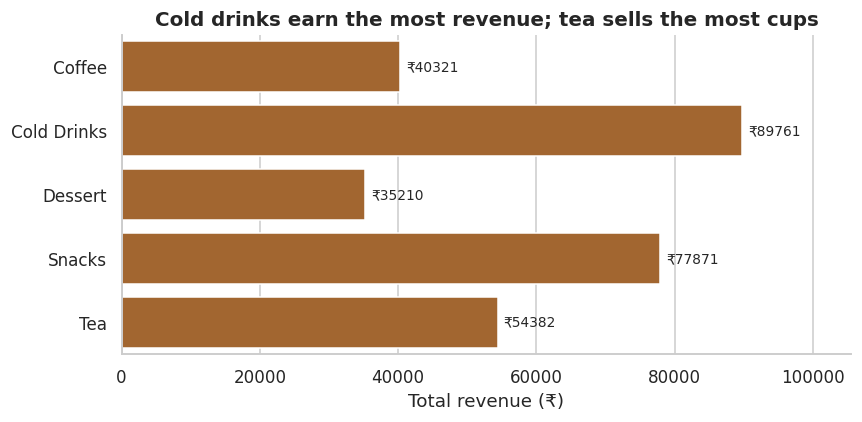

In [28]:
order = cat_perf.index.tolist()
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df.groupby("category", observed=True)["revenue"].sum().reset_index().sort_values("revenue", ascending=False),
            y="category", x="revenue", color=CHAI["tea"], ax=ax)
ax.bar_label(ax.containers[0], fmt="₹%.0f", padding=4, fontsize=9)
ax.set(title="Cold drinks earn the most revenue; tea sells the most cups", xlabel="Total revenue (₹)", ylabel="")
ax.set_xlim(0, ax.get_xlim()[1] * 1.12)
save_fig("01_revenue_by_category")

### 7.2 When does it sell? (line chart)

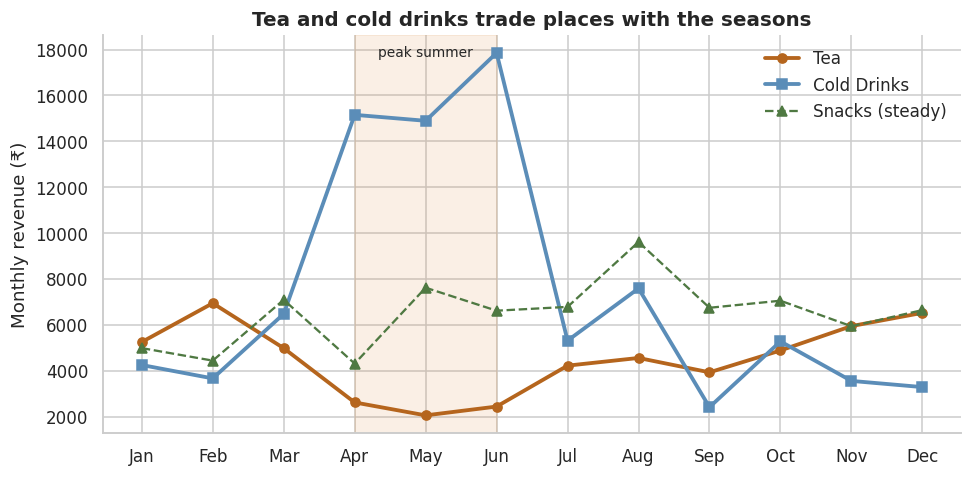

In [29]:
monthly = df.pivot_table(index="month", columns="category", values="revenue", aggfunc="sum", observed=True)
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(months, monthly["Tea"], marker="o", lw=2.5, color=CHAI["tea"], label="Tea")
ax.plot(months, monthly["Cold Drinks"], marker="s", lw=2.5, color=CHAI["sky"], label="Cold Drinks")
ax.plot(months, monthly["Snacks"], marker="^", lw=1.5, ls="--", color=CHAI["leaf"], label="Snacks (steady)")
ax.axvspan(3, 5, color=CHAI["spice"], alpha=.12); ax.text(4, ax.get_ylim()[1]*.95, "peak summer", ha="center", fontsize=9)
ax.set(title="Tea and cold drinks trade places with the seasons", ylabel="Monthly revenue (₹)")
ax.legend(frameon=False)
save_fig("02_monthly_trend")

### 7.3 How fast are we? (histograms)

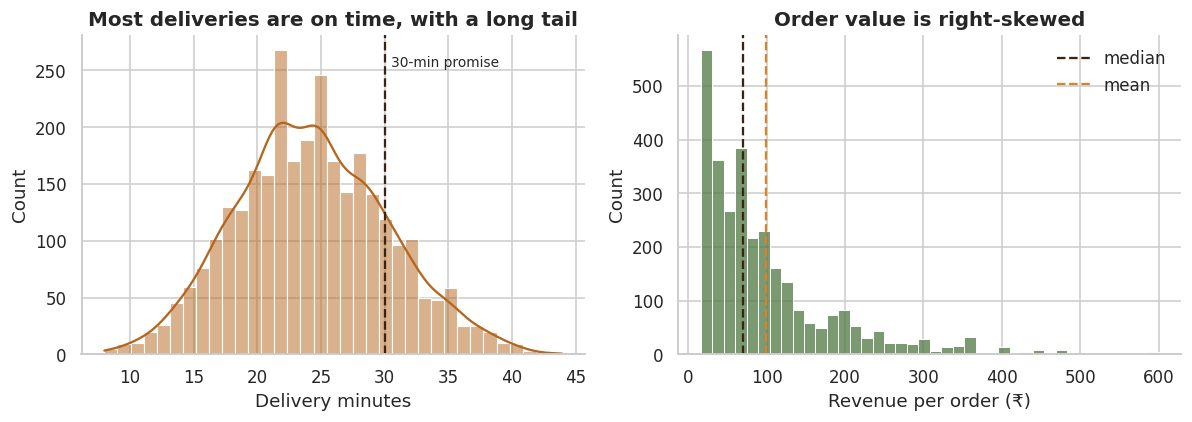

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["delivery_minutes"], bins=35, kde=True, color=CHAI["tea"], ax=axes[0])
axes[0].axvline(LATE_MINUTES, color=CHAI["cup"], ls="--"); axes[0].text(LATE_MINUTES + .5, axes[0].get_ylim()[1]*.9, "30-min promise", fontsize=9)
axes[0].set(title="Most deliveries are on time, with a long tail", xlabel="Delivery minutes")

sns.histplot(df["revenue"], bins=40, color=CHAI["leaf"], ax=axes[1])
axes[1].axvline(df["revenue"].median(), color=CHAI["cup"], ls="--"); axes[1].axvline(df["revenue"].mean(), color=CHAI["spice"], ls="--")
axes[1].set(title="Order value is right-skewed", xlabel="Revenue per order (₹)")
axes[1].legend(["median", "mean"], frameon=False)
save_fig("03_distributions")

### 7.4 Does speed drive satisfaction? (scatter + trend)

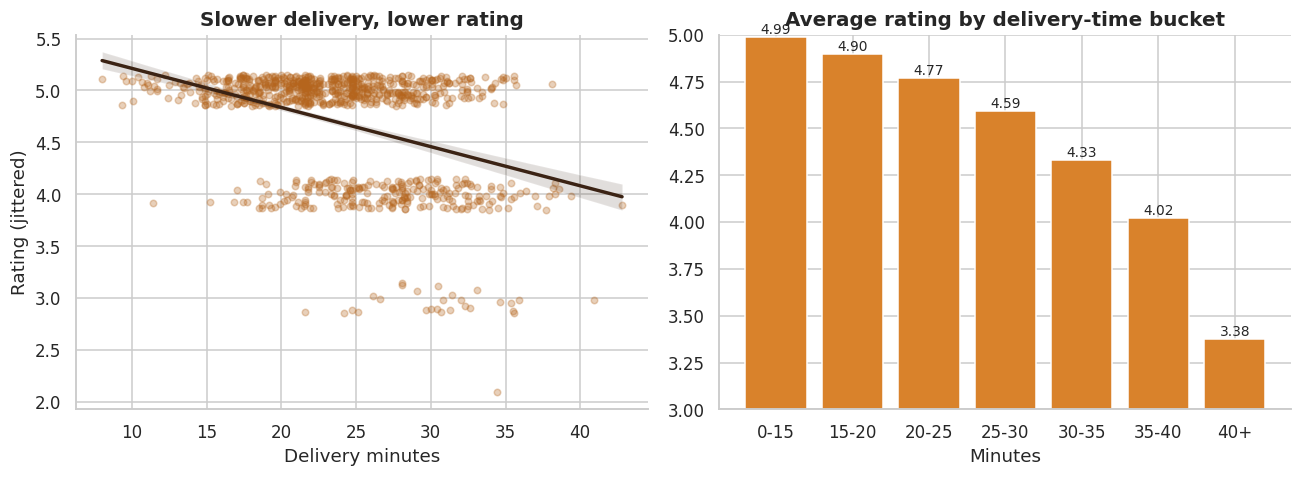

In [31]:
rated = df.dropna(subset=["rating"])
bins = [0, 15, 20, 25, 30, 35, 40, 200]
by_bin = rated.groupby(pd.cut(rated["delivery_minutes"], bins), observed=True)["rating"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.regplot(data=rated.sample(900, random_state=1), x="delivery_minutes", y="rating", y_jitter=.15,
            scatter_kws={"alpha": .3, "color": CHAI["tea"], "s": 18}, line_kws={"color": CHAI["cup"]}, ax=axes[0])
axes[0].set(title="Slower delivery, lower rating", xlabel="Delivery minutes", ylabel="Rating (jittered)")

axes[1].bar([f"{int(i.left)}-{int(i.right)}" if i.right < 200 else f"{int(i.left)}+" for i in by_bin.index], by_bin.values, color=CHAI["spice"])
axes[1].set(title="Average rating by delivery-time bucket", xlabel="Minutes", ylim=(3, 5))
for i, v in enumerate(by_bin.values): axes[1].text(i, v + .02, f"{v:.2f}", ha="center", fontsize=9)
save_fig("04_delivery_vs_rating")

### 7.5 Which formats and times are slow? (box plots)

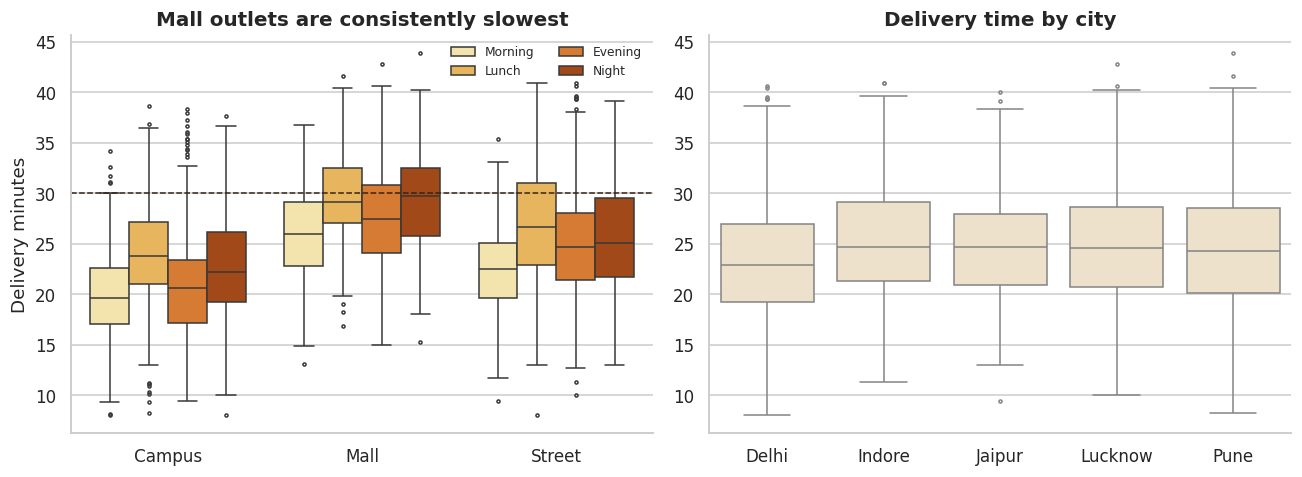

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(data=df, x="store_type", y="delivery_minutes", hue="daypart", palette="YlOrBr", ax=axes[0], fliersize=2)
axes[0].axhline(LATE_MINUTES, color=CHAI["cup"], ls="--", lw=1)
axes[0].set(title="Mall outlets are consistently slowest", xlabel="", ylabel="Delivery minutes")
axes[0].legend(title="", frameon=False, fontsize=8, ncol=2)

sns.boxplot(data=df, x="city", y="delivery_minutes", color=CHAI["milk"], ax=axes[1], fliersize=2)
axes[1].set(title="Delivery time by city", xlabel="", ylabel="")
save_fig("05_delivery_boxplots")

### 7.6 When are we busiest? (heatmap)

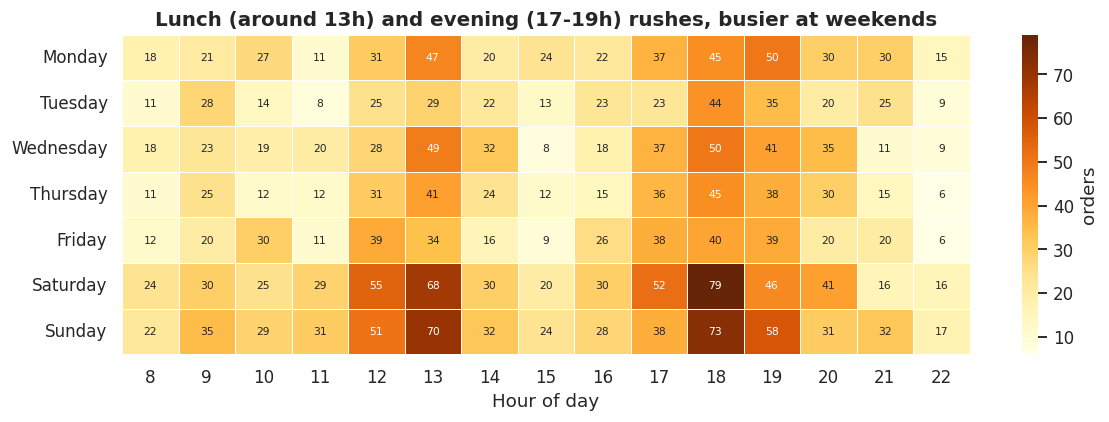

In [33]:
heat = df.pivot_table(index="weekday", columns="order_hour", values="order_id", aggfunc="count", observed=True)
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(heat, cmap="YlOrBr", annot=True, fmt="d", annot_kws={"size": 7}, linewidths=.4, cbar_kws={"label": "orders"}, ax=ax)
ax.set(title="Lunch (around 13h) and evening (17-19h) rushes, busier at weekends", xlabel="Hour of day", ylabel="")
save_fig("06_busy_hours_heatmap")

### 7.7 Do discounts pay off? (point plots)

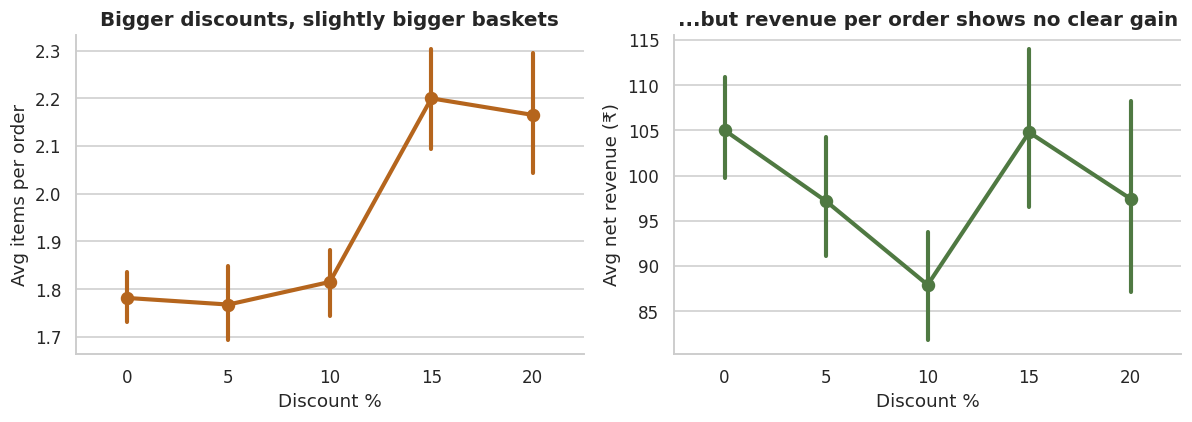

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.pointplot(data=df, x="discount_pct", y="quantity", color=CHAI["tea"], ax=axes[0], errorbar=("ci", 95))
axes[0].set(title="Bigger discounts, slightly bigger baskets", xlabel="Discount %", ylabel="Avg items per order")
sns.pointplot(data=df, x="discount_pct", y="revenue", color=CHAI["leaf"], ax=axes[1], errorbar=("ci", 95))
axes[1].set(title="...but revenue per order shows no clear gain", xlabel="Discount %", ylabel="Avg net revenue (₹)")
save_fig("07_discount_effect")

### 7.8 How do the numbers relate? (correlation heatmap)

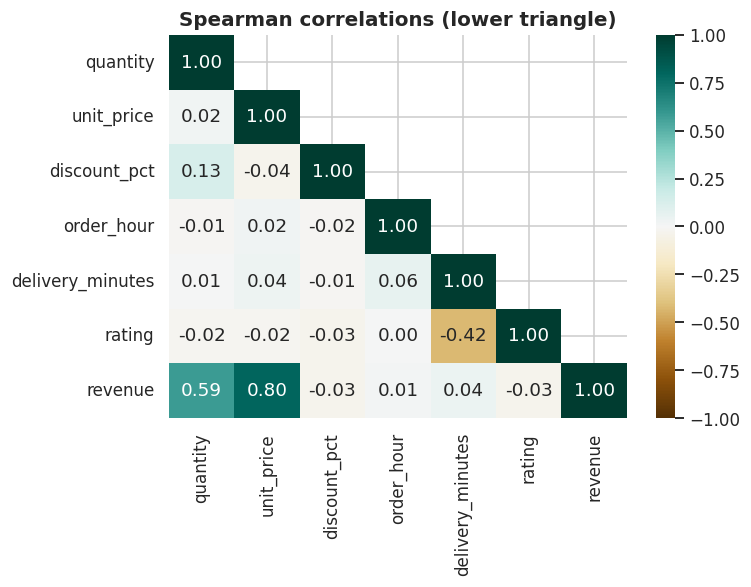

In [35]:
num_cols = ["quantity", "unit_price", "discount_pct", "order_hour", "delivery_minutes", "rating", "revenue"]
corr = df[num_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool), k=1), annot=True, fmt=".2f", cmap="BrBG", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Spearman correlations (lower triangle)")
save_fig("08_correlation_heatmap")

## 8. Descriptive statistics and hypothesis testing
Pictures suggest; statistics confirm. I'll check whether what I *see* is likely to be real or just noise.

In [36]:
desc = df[["quantity", "unit_price", "discount_pct", "delivery_minutes", "rating", "revenue"]].describe().T
desc["skew"] = df[desc.index].skew()
desc["kurtosis"] = df[desc.index].kurt()
desc

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
quantity,"3,000.00",1.86,0.95,1.00,1.00,2.00,2.00,4.00,0.83,-0.34
unit_price,"3,000.00",56.76,35.84,20.00,30.00,40.00,90.00,150.00,0.75,-0.70
discount_pct,"3,000.00",6.42,6.50,0.00,0.00,5.00,10.00,20.00,0.62,-0.78
delivery_minutes,"3,000.00",24.26,5.93,8.00,20.20,24.10,28.30,43.90,0.17,-0.20
rating,"2,661.00",4.67,0.54,2.00,4.00,5.00,5.00,5.00,-1.38,1.04
revenue,"3,000.00",99.18,88.02,16.00,36.00,70.00,120.00,600.00,1.96,4.58


In [37]:
print("Categorical summary\n")
for c in ["category", "payment_mode", "store_type", "daypart"]:
    print(df[c].value_counts(normalize=True).mul(100).round(1).to_frame("%").T.to_string(), "\n")

Categorical summary

category   Tea  Snacks  Cold Drinks  Coffee  Dessert
%        38.50   29.60        14.90   12.00     5.00 

payment_mode   UPI  Cash  Card  Wallet  Unknown
%            54.90 19.00 18.20    6.10     1.70 

store_type  Campus  Street  Mall
%            44.30   35.40 20.40 

daypart  Evening  Lunch  Morning  Night
%          36.90  29.50    19.20  14.50 



### Question 2 tested properly: does delivery time affect rating?
* **Correlation** gives the strength of the relationship.
* **Welch's t-test** compares ratings of on-time vs late orders (it doesn't assume equal variances).
* **Cohen's d** gives the *size* of the difference, because a tiny p-value alone doesn't say whether it matters.
* **Bootstrap** gives a confidence interval using only NumPy resampling.

In [38]:
rated = df.dropna(subset=["rating"])
pear = stats.pearsonr(rated["delivery_minutes"], rated["rating"])
spear = stats.spearmanr(rated["delivery_minutes"], rated["rating"])
print(f"Pearson  r = {pear.statistic:.3f} (p={pear.pvalue:.1e})")
print(f"Spearman ρ = {spear.statistic:.3f} (p={spear.pvalue:.1e})\n")

late, ontime = rated.loc[rated.is_late, "rating"], rated.loc[~rated.is_late, "rating"]
t = stats.ttest_ind(late, ontime, equal_var=False)
pooled = np.sqrt((late.var() + ontime.var()) / 2)
d_eff = (late.mean() - ontime.mean()) / pooled
print(f"On-time: mean rating {ontime.mean():.2f} (n={len(ontime)})")
print(f"Late   : mean rating {late.mean():.2f} (n={len(late)})")
print(f"Welch t = {t.statistic:.2f}, p = {t.pvalue:.1e}, Cohen's d = {d_eff:.2f}\n")

# bootstrap the difference in means
rng = np.random.default_rng(SEED)
diffs = np.array([rng.choice(late, len(late)).mean() - rng.choice(ontime, len(ontime)).mean() for _ in range(5000)])
lo, hi = np.percentile(diffs, [2.5, 97.5])
print(f"Bootstrap 95% CI for (late - on-time) rating: [{lo:.2f}, {hi:.2f}]")

Pearson  r = -0.442 (p=1.8e-127)
Spearman ρ = -0.424 (p=1.4e-116)

On-time: mean rating 4.76 (n=2211)
Late   : mean rating 4.24 (n=450)
Welch t = -15.68, p = 6.5e-46, Cohen's d = -0.90



Bootstrap 95% CI for (late - on-time) rating: [-0.58, -0.45]


In [39]:
# Question 4: is the discount -> basket-size link statistically real?
groups = [g["quantity"].values for _, g in df.groupby("discount_pct")]
kw = stats.kruskal(*groups)
rho = stats.spearmanr(df["discount_pct"], df["quantity"])
promo = df[df.discount_pct >= 15]; regular = df[df.discount_pct < 15]
print(f"Kruskal-Wallis across discount levels: H={kw.statistic:.1f}, p={kw.pvalue:.1e}")
print(f"Spearman discount vs quantity: ρ={rho.statistic:.3f}")
print(f"Avg items/order: promo (>=15%) {promo.quantity.mean():.2f} vs regular {regular.quantity.mean():.2f}")
print(f"Avg net revenue/order: promo ₹{promo.revenue.mean():.1f} vs regular ₹{regular.revenue.mean():.1f}")

Kruskal-Wallis across discount levels: H=89.2, p=2.0e-18
Spearman discount vs quantity: ρ=0.129
Avg items/order: promo (>=15%) 2.19 vs regular 1.79
Avg net revenue/order: promo ₹101.9 vs regular ₹98.5


## 9. Bonus: a small scikit-learn model
Can we predict a rating from what we know about an order? This isn't the main point of the project; it's a check that the relationships I found hold up when a model has to *use* them. I compare against a naive baseline, because a model is only impressive if it beats "just guess the average."

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

features_num = ["delivery_minutes", "discount_pct", "quantity", "order_hour"]
features_cat = ["store_type", "category", "daypart"]
data = df.dropna(subset=["rating"]).copy()
for c in features_cat: data[c] = data[c].astype(str)
X, y = data[features_num + features_cat], data["rating"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED)

prep = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), features_cat)], remainder="passthrough")
models = {"Baseline (predict mean)": DummyRegressor(),
          "Linear Regression": LinearRegression(),
          "Random Forest": RandomForestRegressor(n_estimators=200, min_samples_leaf=10, random_state=SEED, n_jobs=-1)}
rows, fitted = [], {}
for name, mdl in models.items():
    pipe = Pipeline([("prep", prep), ("model", mdl)]).fit(X_tr, y_tr)
    pred = pipe.predict(X_te); fitted[name] = pipe
    rows.append({"model": name, "MAE": mean_absolute_error(y_te, pred), "R²": r2_score(y_te, pred)})
pd.DataFrame(rows).set_index("model")

,MAE,R²
model,,
Baseline (predict mean),0.46,-0.00
Linear Regression,0.36,0.24
Random Forest,0.35,0.23


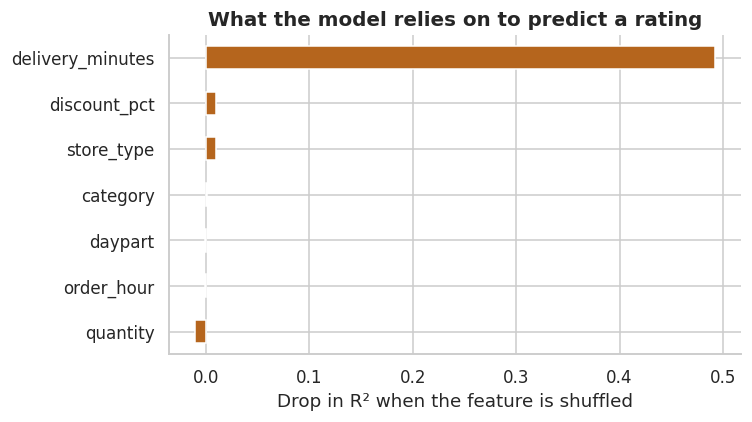

In [41]:
pi = permutation_importance(fitted["Random Forest"], X_te, y_te, n_repeats=10, random_state=SEED)
imp = pd.Series(pi.importances_mean, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
imp.plot.barh(color=CHAI["tea"], ax=ax)
ax.set(title="What the model relies on to predict a rating", xlabel="Drop in R² when the feature is shuffled")
save_fig("09_feature_importance")

**Reading the model results honestly:** both models beat the naive baseline (MAE drops from about 0.46 to about 0.35 stars), but R² is only around 0.24. That makes sense: ratings are whole numbers with lots of individual randomness, so no model should predict them perfectly. The useful takeaway is the importance chart above. Delivery time should dominate, which agrees with the correlation and t-test. The forest doesn't beat plain linear regression, a good reminder that a fancier model isn't automatically a better one.

## 10. Insights, recommendations and honest limitations
The cell below pulls the headline numbers straight from the data, so the summary can never drift out of sync with the analysis.

In [42]:
summer = df[df.month.isin([4, 5, 6])].groupby("category", observed=True)["revenue"].sum()
winter = df[df.month.isin([12, 1, 2])].groupby("category", observed=True)["revenue"].sum()
worst = store_kpi.sort_values("late_rate", ascending=False).iloc[0]
best = store_kpi.sort_values("late_rate").iloc[0]
type_late = df.groupby("store_type", observed=True)["is_late"].mean().mul(100).round(1)

print(f"1) SEASONS  : Cold Drinks = {summer['Cold Drinks']/summer.sum():.1%} of summer revenue vs {winter['Cold Drinks']/winter.sum():.1%} in winter;")
print(f"              Tea = {winter['Tea']/winter.sum():.1%} of winter revenue vs {summer['Tea']/summer.sum():.1%} in summer.")
print(f"2) DELIVERY : late orders average {late.mean():.2f} stars vs {ontime.mean():.2f} on-time (d = {d_eff:.2f}); overall {df.is_late.mean():.1%} of orders are late.")
print(f"3) OUTLETS  : late-rate by format -> {type_late.to_dict()}")
print(f"              worst outlet {worst.store_id} ({worst.city}, {worst.store_type}) at {worst.late_rate:.1f}% late; best {best.store_id} at {best.late_rate:.1f}%.")
print(f"4) DISCOUNTS: promo (>=15%) baskets are {promo.quantity.mean()/regular.quantity.mean()-1:+.1%} larger, "
      f"but net revenue per order is {promo.revenue.mean()/regular.revenue.mean()-1:+.1%} vs regular.")
print(f"5) LOYALTY  : Loyal customers are {(customers.segment=='Loyal').mean():.1%} of the base and {customers.loc[customers.segment=='Loyal','lifetime_spend'].sum()/customers['lifetime_spend'].sum():.1%} of spend.")

1) SEASONS  : Cold Drinks = 51.5% of summer revenue vs 17.5% in winter;
              Tea = 29.2% of winter revenue vs 7.7% in summer.
2) DELIVERY : late orders average 4.24 stars vs 4.76 on-time (d = -0.90); overall 16.9% of orders are late.
3) OUTLETS  : late-rate by format -> {'Campus': 8.5, 'Mall': 32.9, 'Street': 18.1}
              worst outlet S02 (Lucknow, Mall) at 36.1% late; best S06 at 8.3%.
4) DISCOUNTS: promo (>=15%) baskets are +22.3% larger, but net revenue per order is +3.4% vs regular.
5) LOYALTY  : Loyal customers are 23.3% of the base and 39.9% of spend.


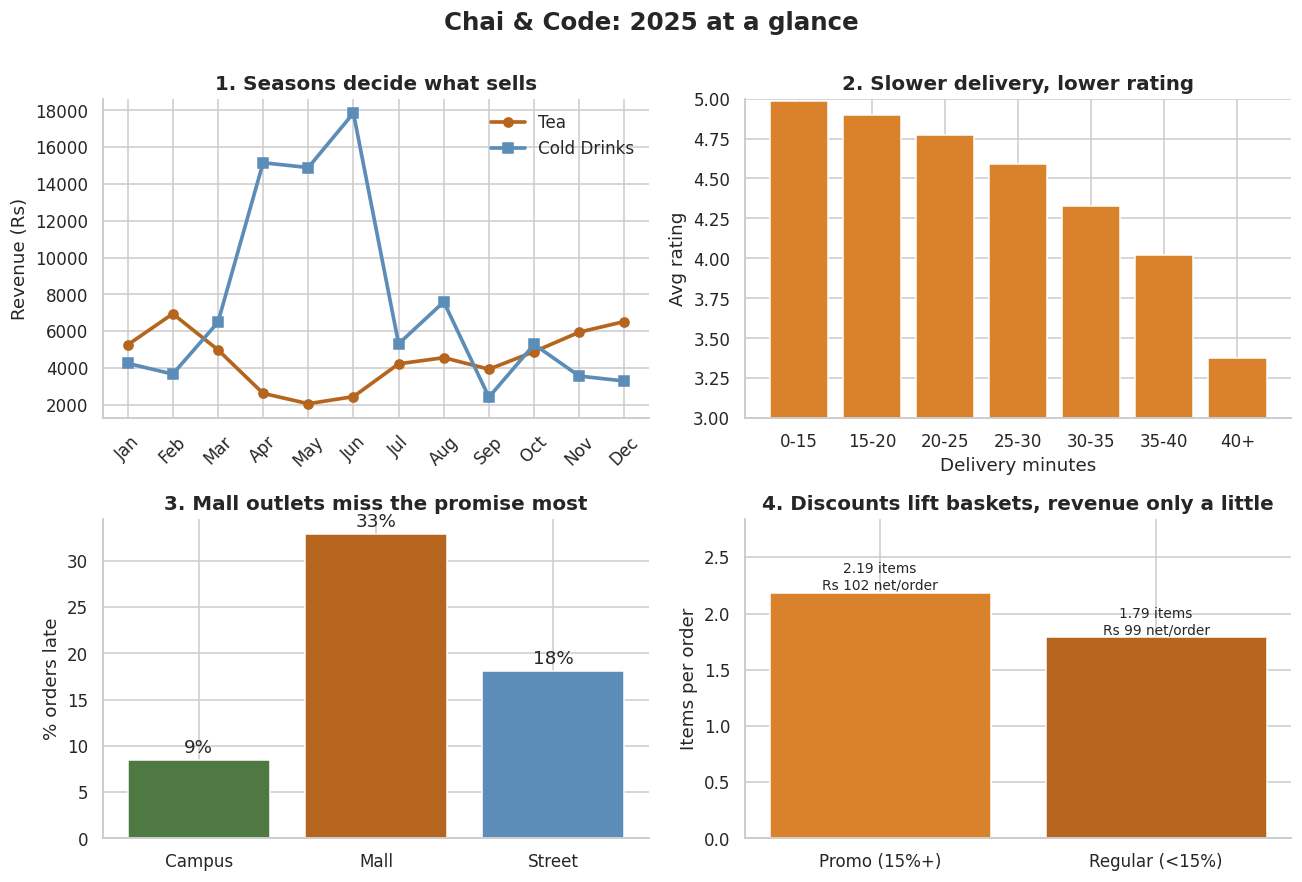

In [43]:
# One-page summary: the four questions, four answers
type_late_s = df.groupby("store_type", observed=True)["is_late"].mean().mul(100)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(months, monthly["Tea"], marker="o", color=CHAI["tea"], lw=2.4, label="Tea")
axes[0, 0].plot(months, monthly["Cold Drinks"], marker="s", color=CHAI["sky"], lw=2.4, label="Cold Drinks")
axes[0, 0].set(title="1. Seasons decide what sells", ylabel="Revenue (Rs)"); axes[0, 0].legend(frameon=False)
axes[0, 0].tick_params(axis="x", rotation=45)

axes[0, 1].bar([f"{int(i.left)}-{int(i.right)}" if i.right < 200 else f"{int(i.left)}+" for i in by_bin.index], by_bin.values, color=CHAI["spice"])
axes[0, 1].set(title="2. Slower delivery, lower rating", xlabel="Delivery minutes", ylabel="Avg rating", ylim=(3, 5))

bars = axes[1, 0].bar(type_late_s.index, type_late_s.values, color=[CHAI["leaf"], CHAI["tea"], CHAI["sky"]])
axes[1, 0].bar_label(bars, fmt="%.0f%%", padding=2)
axes[1, 0].set(title="3. Mall outlets miss the promise most", ylabel="% orders late")

grp = np.where(df["discount_pct"] >= 15, "Promo (15%+)", "Regular (<15%)")
g = df.groupby(grp).agg(items=("quantity", "mean"), net=("revenue", "mean"))
bars = axes[1, 1].bar(g.index, g["items"], color=[CHAI["spice"], CHAI["tea"]])
for b_, (_, r_) in zip(bars, g.iterrows()):
    axes[1, 1].text(b_.get_x() + b_.get_width() / 2, r_["items"] + .03, f"{r_['items']:.2f} items\nRs {r_['net']:.0f} net/order", ha="center", fontsize=9)
axes[1, 1].set(title="4. Discounts lift baskets, revenue only a little", ylabel="Items per order", ylim=(0, g["items"].max() * 1.3))

fig.suptitle("Chai & Code: 2025 at a glance", fontsize=16, fontweight="bold", y=1.0)
save_fig("00_dashboard")

### What I'd recommend (if this were a real business)
1. **Plan the menu and stock by season.** Push cold drinks from April to June and tea from November to February, instead of running one flat menu all year.
2. **Fix delivery before spending on marketing.** Late orders earn measurably lower ratings. Mall outlets and peak hours (lunch and evening) are where the promise breaks, so extra riders or a pre-prep system there will pay off most.
3. **Rethink blanket discounts.** Discounts of 15%+ lift basket size by roughly a fifth, but net revenue per order only rises by a few percent, and I have no margin data to say whether that's profitable. Test targeted offers (for example, a snack bundled with tea) against blanket percentage cuts before scaling either.
4. **Look after the loyal minority.** A small group of repeat customers drives a disproportionate share of spend, so they deserve a proper loyalty programme.

### Limitations (things I'm not going to pretend away)
* **The data is synthetic.** I planted the seasonal and delivery patterns, so finding them shows my method works, not that these facts are universal.
* **Correlation isn't causation.** Even in real data, slow delivery and low ratings could share a hidden cause (rain, staff shortage).
* **Missing ratings** were left as-is. If unhappy customers are the ones who don't rate, real-world averages would be biased upwards.
* **Median imputation** for delivery time shrinks variance a little. I kept an `delivery_imputed` flag so this can be revisited.
* Each outlet has only ~1 year of data, so year-on-year trends can't be assessed.

### What I learned
* Cleaning took the most thinking, and every choice (drop vs fill vs leave) changes the answers downstream, so writing the reasoning down matters as much as the code.
* Using `merge(validate=...)` and `assert` as safety nets caught problems that a quick visual check would have missed.
* An effect size (Cohen's d) tells a much more honest story than a p-value alone.

### Next steps
Try a real dataset (Zomato/Swiggy-style open data), add a time-series forecast (Prophet or SARIMA) for monthly demand, and build a small Streamlit dashboard on top of `orders_clean.csv`.

---
**Manindra Shukla** | [GitHub](https://github.com/Manindra07) | manindrashukla77@gmail.com | Yuva Intern by Henry Harvin, Project 2

*Reproduce it: clone the repo, `pip install -r requirements.txt`, and run all cells. The fixed seed (`SEED = 42`) gives the same results every time.*